##### 1. Load Libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

##### 2. Load and Add Target Columns (normalized from preprocessing notebook)
In this cell, data is read from the csv files in the "data" folder and imported as dataframes in Python. The target column is added, then encoded to a numerical value for the model. The target map is exported to keep track of which classification value is associated with which species. This export can be turned on/off based on the argument given to the function (shown in the code comment below). 

In [2]:
# optional export - set to True (or pass export_target_map=True) to write target_encoding_map.json
EXPORT_TARGET_MAP = False

# dictionary for value insertion for target column
targets = {
    "1-9": "1:9 | Staph : PAO",
    "3-7": "3:7 | Staph : PAO",
    "5-5": "5:5 | Staph : PAO",
    "7-3": "7:3 | Staph : PAO",
    "9-1": "9:1 | Staph : PAO",
    "STAPH": "10:0 | Staph : PAO",
    "PAO1": "0:10 | Staph : PAO", 
    "Corn" : "Corn", 
    "FAE" : "FAE",
    "E.coli" : "E.coli", 
    "Malt" : "Malt"
}

def read_all_csvs_to_df(folder_paths, export_target_map=EXPORT_TARGET_MAP):
    if isinstance(folder_paths, (str, os.PathLike)):
        folder_paths = [folder_paths]

    file_paths = []
    for folder_path in folder_paths:
        file_paths.extend(
            os.path.join(folder_path, file_name)
            for file_name in sorted(os.listdir(folder_path))
            if file_name.endswith(".csv")
        )

    if not file_paths:
        raise ValueError(f"No CSV files found in folders: {folder_paths}")

    loaded_files = []
    for file_path in file_paths:
        file_name = os.path.basename(file_path)
        df = pd.read_csv(file_path, header=None)

        # adding the target column values based on the target dictionary above
        target_value = next((value for key, value in targets.items() if key in file_name), None)  

        if target_value is None:
            raise ValueError(f"No target mapping found for file: {file_name}")

        loaded_files.append((file_name, df, target_value))

    min_feature_cols = min(df.shape[1] for _, df, _ in loaded_files)
    dataframes = []

    for i, (file_name, df, target_value) in enumerate(loaded_files):
        if df.shape[1] > min_feature_cols:
            print(f"Trimming {file_name} from {df.shape[1]} to {min_feature_cols} spectral columns.")
            df = df.iloc[:, :min_feature_cols]

        if i != 0:
            df = df.iloc[1:].reset_index(drop=True)

        df = df.copy()
        df["target"] = target_value
        dataframes.append(df)

    combined_df = pd.concat(dataframes, ignore_index=True).copy()

    # label encoding for RF model 
    label_encoder = LabelEncoder()
    combined_df["target_encoded"] = label_encoder.fit_transform(combined_df["target"])

    # exporting target value map
    target_map = {
        str(original): int(encoded)
        for original, encoded in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))
    }

    # keep the map available in memory so later cells never depend on the file export
    global target_encoding_map
    target_encoding_map = target_map

    # optional export (off by default) - pass export_target_map=True to write the json
    if export_target_map:
        json_path = os.path.join(os.getcwd(), "target_encoding_map.json")
        with open(json_path, "w") as f:
            json.dump(target_map, f, indent=4)


    return combined_df


# accessing the main data folder
folder_paths = [
    os.path.join("..", "data", "mixed_ratio"),
    os.path.join("..", "data", "six_single_species")
]
df = read_all_csvs_to_df(folder_paths)


Trimming 1-9_S-P_1.csv from 389 to 388 spectral columns.
Trimming 1-9_S-P_4.csv from 389 to 388 spectral columns.
Trimming 3-7_S-P_1.csv from 389 to 388 spectral columns.
Trimming 5-5_S-P_1.csv from 389 to 388 spectral columns.
Trimming 5-5_S-P_4.csv from 389 to 388 spectral columns.
Trimming 7-3_S-P_1.csv from 389 to 388 spectral columns.
Trimming 9-1_S-P_1.csv from 389 to 388 spectral columns.
Trimming 9-1_S-P_4.csv from 389 to 388 spectral columns.
Trimming Corn.csv from 389 to 388 spectral columns.
Trimming E.coli.csv from 389 to 388 spectral columns.
Trimming FAE.csv from 389 to 388 spectral columns.
Trimming Malt.csv from 389 to 388 spectral columns.
Trimming PAO1.csv from 389 to 388 spectral columns.
Trimming STAPH.csv from 389 to 388 spectral columns.


##### 3. Label Data and Drop Target Column
In this cell, feature labels are changed and the target column is dropped. When importing the data from a csv into the dataframe, the feature labels (wavelengths) are changed to a numerical scale from 0 to the number of features/columns in the data. This remapping is exported as a json file to keep track of what is being looked at. This export can also be disabled through argument changes in the function. Since the logic of the previous cell required the string target column, it gets removed here instead of the previous cell.

In [3]:
# optional export - set to True (or pass export_feature_map=True) to write feature_map.json
EXPORT_FEATURE_MAP = False


def label_data(dataframe, export_feature_map=EXPORT_FEATURE_MAP):
    target_idx = dataframe.columns.get_loc("target")
    feature_cols = dataframe.columns[:target_idx]

    feature_values = dataframe.iloc[0, :target_idx]
    feature_labels = range(1, len(feature_cols) + 1)

    clean_df = dataframe.iloc[1:].reset_index(drop=True).copy()
    clean_df = clean_df.rename(columns=dict(zip(feature_cols, feature_labels)))

    feature_map = {str(label): value for label, value in zip(feature_labels, feature_values)}

    # keep the map available in memory so later cells never depend on the file export
    global feature_encoding_map
    feature_encoding_map = feature_map

    # optional export (off by default) - pass export_feature_map=True to write the json
    if export_feature_map:
        json_path = os.path.join(os.getcwd(), "feature_map.json")
        with open(json_path, "w") as f:
            json.dump(feature_map, f, indent=4)

    clean_df = clean_df.drop(columns=['target'], errors="ignore")

    return clean_df

clean_df = label_data(df)

#for testing
#print(clean_df.head())
#df.to_csv("file_bad.csv")

##### 4. Implement ZCA

In [4]:
plt.rcParams.update({
    "font.family": "Arial",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
})

print("Imports complete.")


def fit_transform_zca(X, epsilon=1e-5):
    """Standard ZCA whitening: X_zca = X_std @ U @ diag(1/sqrt(S + eps)) @ U.T."""
    covariance = np.cov(X, rowvar=False, bias=True)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)

    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    whitening_matrix = eigenvectors @ np.diag(1.0 / np.sqrt(eigenvalues + epsilon)) @ eigenvectors.T
    X_zca = X @ whitening_matrix

    return X_zca, whitening_matrix, eigenvalues, eigenvectors


def group_separation_scores(X, y):
    """Between-group / within-group score for selecting useful ZCA visualization axes."""
    y = np.asarray(y)
    overall_mean = X.mean(axis=0)
    between = np.zeros(X.shape[1])
    within = np.zeros(X.shape[1])

    for grp in np.unique(y):
        group_values = X[y == grp]
        if len(group_values) == 0:
            continue

        group_mean = group_values.mean(axis=0)
        between += len(group_values) * (group_mean - overall_mean) ** 2
        within += ((group_values - group_mean) ** 2).sum(axis=0)

    return between / (within + 1e-12)


def run_zca_spectral_style(
    dataframe,
    target_col="target_encoded",
    epsilon=1e-5,
    top_n=15,
    five_points_per_group=True,
    show_point_labels=False,
    save_prefix=None         # e.g. "Fig4_ZCA"
):
    if target_col not in dataframe.columns:
        raise ValueError(f"Target column '{target_col}' not found in dataframe.")

    # Split features / labels
    feature_cols = [c for c in dataframe.columns if c != target_col]
    X = dataframe[feature_cols].to_numpy(dtype=float)
    y = dataframe[target_col].to_numpy()

    # JSON Mapping for species names
    target_map_raw = target_encoding_map

    # reverse mapping: {"label": 0} -> {0: "label"}
    target_map = {v: k for k, v in target_map_raw.items()}
    sample_labels = [target_map[val] for val in y]

    # Standardize before ZCA so every spectral variable contributes on the same scale
    scaler = StandardScaler()
    X_std = scaler.fit_transform(X)

    # ZCA whitening
    zca_scores, zca_matrix, eigenvalues, eigenvectors = fit_transform_zca(X_std, epsilon=epsilon)
    separation_scores = group_separation_scores(zca_scores, y)
    axis_idx = np.argsort(separation_scores)[::-1][:2]

    if len(axis_idx) < 2:
        raise ValueError("At least two feature columns are required to visualize ZCA results.")

    zca_df = pd.DataFrame(zca_scores, columns=feature_cols)
    zca_df[target_col] = y
    zca_df["sample_label"] = sample_labels

    print("ZCA whitening complete.")
    print(f"  epsilon: {epsilon}")
    print(f"  retained dimensions: {zca_scores.shape[1]}")
    print(f"  plot axes: feature {feature_cols[axis_idx[0]]} and feature {feature_cols[axis_idx[1]]}")

    # Feature labels for visualization
    try:
        feature_axis_labels = np.array([float(c) for c in feature_cols])
        feature_axis_is_numeric = True
    except Exception:
        feature_axis_labels = np.array(feature_cols)
        feature_axis_is_numeric = False

    unique_groups = list(dict.fromkeys(y))

    marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]
    color_cycle = [
        "#2166AC", "#4DAF4A", "#FF7F00", "#984EA3", "#A65628",
        "#E41A1C", "#17BECF", "#BCBD22", "#7F7F7F", "#1F77B4"
    ]

    group_markers = {
        grp: marker_cycle[i % len(marker_cycle)]
        for i, grp in enumerate(unique_groups)
    }
    group_colors = {
        grp: color_cycle[i % len(color_cycle)]
        for i, grp in enumerate(unique_groups)
    }

    fig, axes = plt.subplots(1, 2, figsize=(17, 7))

    # ZCA score plot using the two most group-separating whitened variables
    ax = axes[0]
    for grp in unique_groups:
        idx = np.where(y == grp)[0]

        if five_points_per_group:
            idx_to_plot = idx[:5]
        else:
            idx_to_plot = idx

        points = zca_scores[idx_to_plot][:, axis_idx]

        ax.scatter(
            points[:, 0],
            points[:, 1],
            c=group_colors.get(grp, "#888888"),
            s=90,
            marker=group_markers.get(grp, "o"),
            edgecolors="white",
            linewidths=0.5,
            zorder=3,
            label=target_map.get(grp, str(grp)),
        )

        if show_point_labels:
            for i in idx_to_plot:
                ax.annotate(
                    sample_labels[i],
                    (zca_scores[i, axis_idx[0]], zca_scores[i, axis_idx[1]]),
                    xytext=(5, 3),
                    textcoords="offset points",
                    fontsize=6.5,
                    color=group_colors.get(grp, "#888888"),
                )

    ax.axhline(0, color="gray", lw=0.5, ls="--")
    ax.axvline(0, color="gray", lw=0.5, ls="--")
    ax.set_xlabel(f"ZCA feature {feature_cols[axis_idx[0]]}")
    ax.set_ylabel(f"ZCA feature {feature_cols[axis_idx[1]]}")
    ax.set_title("ZCA-Whitened Spectra\n(Top Two Group-Separating Variables)")
    ax.legend(
        title="Ratio | Species",
        fontsize=8,
        title_fontsize=9,
        loc="best"
    )

    # Top ZCA-whitened variables by group separation
    ax2 = axes[1]
    top_n = min(top_n, zca_scores.shape[1])
    top_idx = np.argsort(separation_scores)[::-1][:top_n]

    top_features = feature_axis_labels[top_idx]
    top_scores = separation_scores[top_idx]
    ypos = np.arange(top_n)

    ax2.barh(ypos, top_scores, height=0.55, color="#2166AC", alpha=0.85)
    ax2.set_yticks(ypos)
    if feature_axis_is_numeric:
        ax2.set_yticklabels([f"{w:.0f}" for w in top_features], fontsize=8)
        ax2.set_title(f"Top {top_n} ZCA Variables by Group Separation")
    else:
        ax2.set_yticklabels([str(w) for w in top_features], fontsize=8)
        ax2.set_title(f"Top {top_n} ZCA Features by Group Separation")

    ax2.set_xlabel("Between-group / within-group score")
    ax2.invert_yaxis()

    plt.suptitle("ZCA Whitening - Spectral Clustering", fontsize=12, fontweight="bold")
    plt.tight_layout()

    # optional figure export (off by default) - pass save_prefix="MyFigure" to write files
    if save_prefix is not None:
        plt.savefig(f"{save_prefix}.pdf", bbox_inches="tight")
        plt.savefig(f"{save_prefix}.png", dpi=200, bbox_inches="tight")

    plt.show()

    return {
        "zca_df": zca_df,
        "zca_matrix": zca_matrix,
        "scaler": scaler,
        "zca_scores": zca_scores,
        "separation_scores": separation_scores,
        "selected_axis_indices": axis_idx,
        "eigenvalues": eigenvalues,
        "eigenvectors": eigenvectors,
        "feature_columns": feature_cols,
    }


Imports complete.


##### 5. Visualize the ZCA

ZCA whitening complete.
  epsilon: 1e-05
  retained dimensions: 388
  plot axes: feature 80 and feature 77


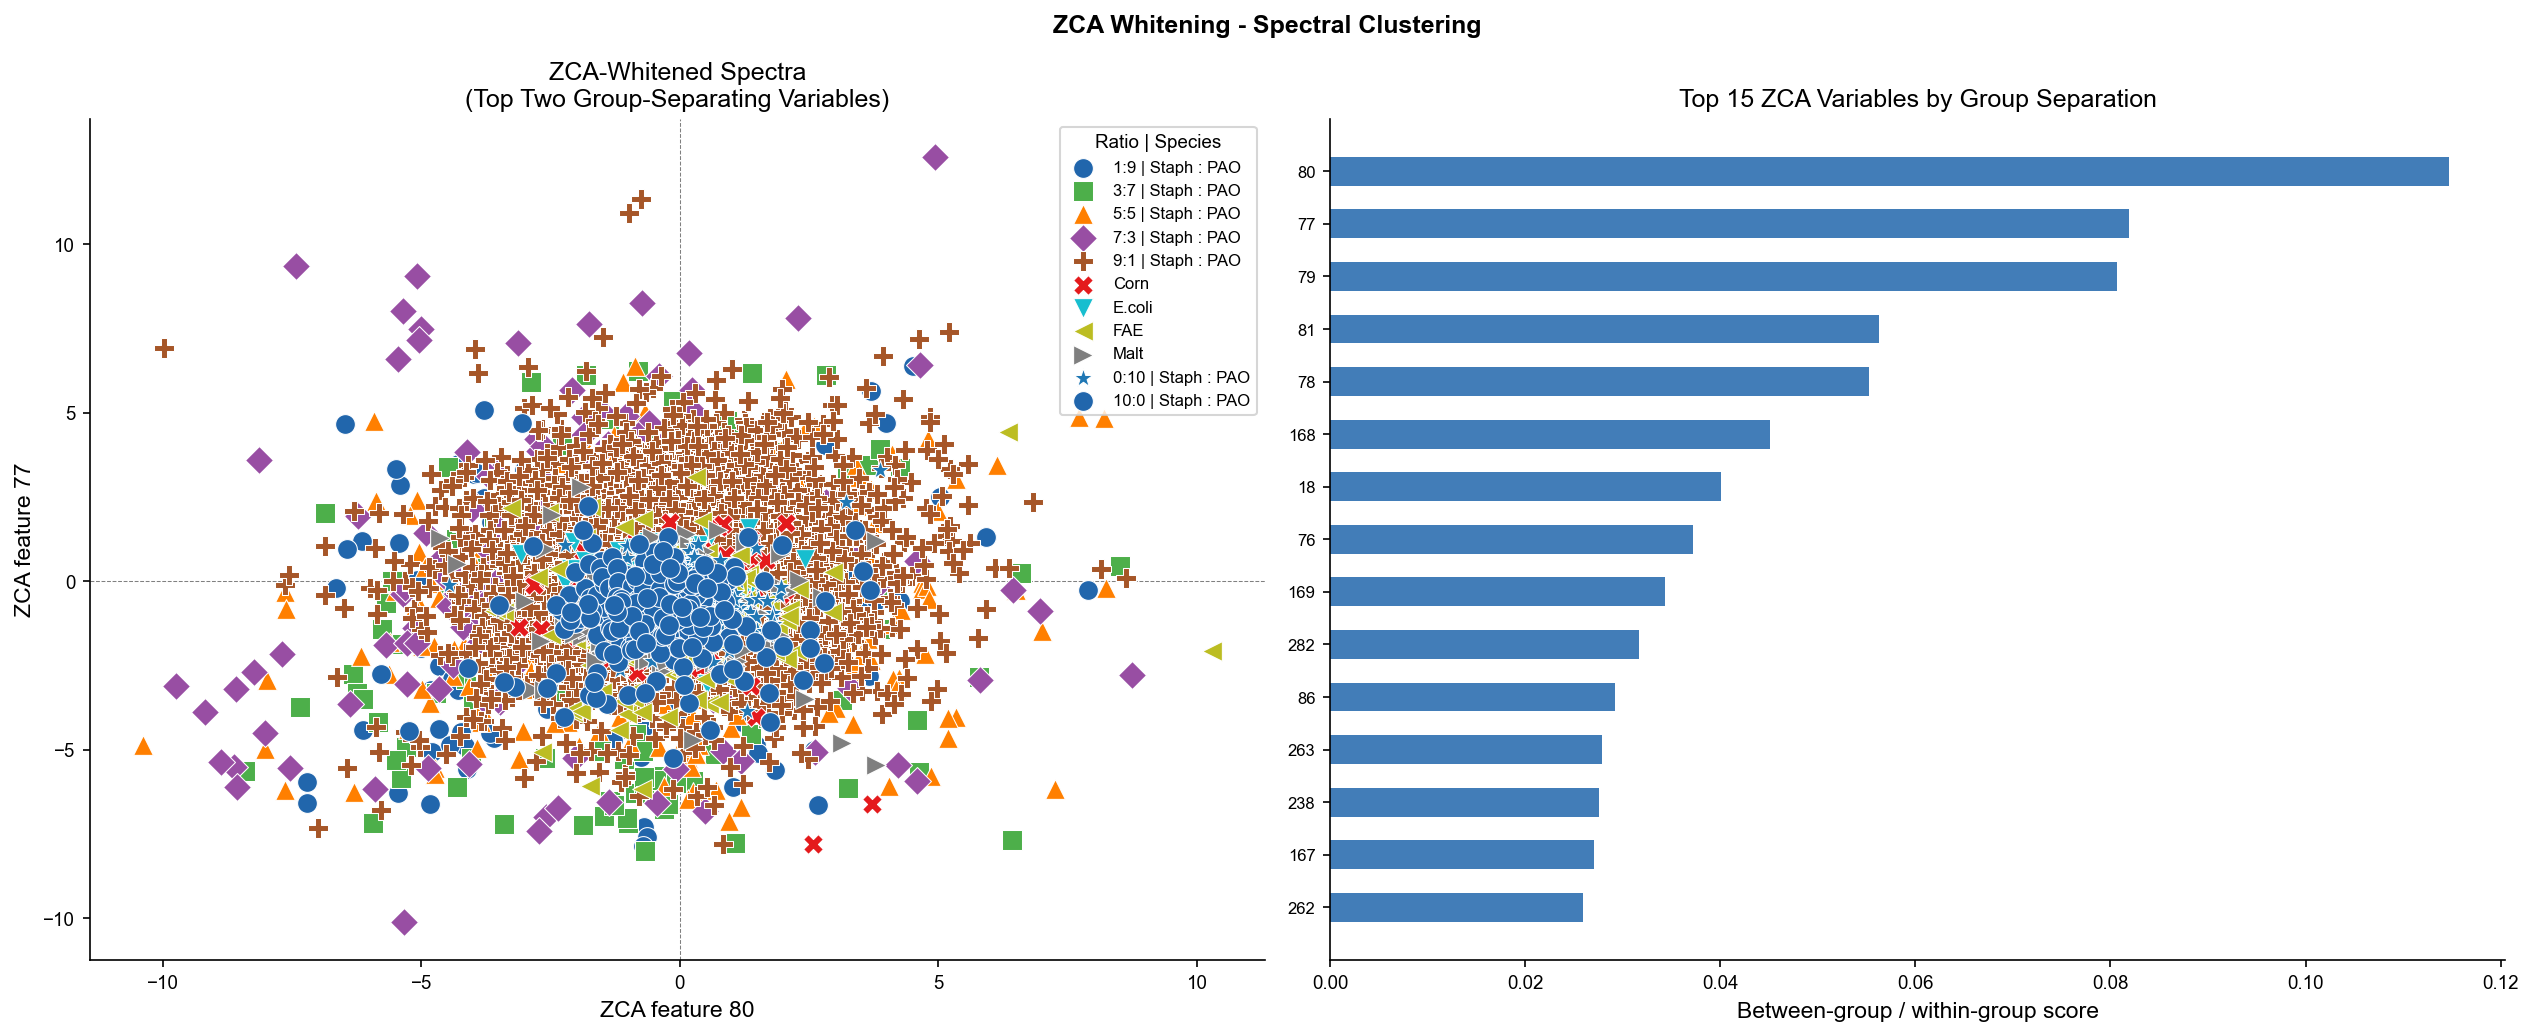

In [5]:
results = run_zca_spectral_style(
    clean_df,
    target_col="target_encoded",
    epsilon=1e-5,
    top_n=15,
    save_prefix=None,
    five_points_per_group=False
)

zca_df = results["zca_df"]
zca_matrix = results["zca_matrix"]
zca_scaler = results["scaler"]
